In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.model_selection import train_test_split


In [2]:
df_hist = pd.read_excel('EAL_Linking_Data.xlsx',sheet_name='Historic schedule',header=4)
df_fut  = pd.read_excel('EAL_Linking_Data.xlsx',sheet_name='Future schedule',header=4)


In [3]:
df_hist.head(15)

,Date and Time,Passenger/Cargo,Flight ID,Turnaround Flight ID,Arrival / Departure,Aircraft Type,Airline,Origin / Destination
0,2023-06-01 00:00:00,Commercial,2719556,2655707,A,C,FR,VLC
1,2023-06-01 00:05:00,Commercial,2719557,2655734,A,C,FR,KUN
2,2023-06-01 00:15:00,Commercial,2655685,2719558,A,C,FR,OPO
3,2023-06-01 00:30:00,Commercial,2655686,2655729,A,C,U2,DLM
4,2023-06-01 01:10:00,Cargo,2742844,2655967,A,C,NPT,STN
5,2023-06-01 01:15:00,Commercial,2655689,2655723,A,C,LS,TFS
6,2023-06-01 01:20:00,Commercial,2749224,2655728,A,C,U2,ATH
7,2023-06-01 01:25:00,Commercial,2655690,2655715,A,C,U2,HER
8,2023-06-01 01:30:00,Cargo,2655691,2655983,A,C,NPT,EMA
9,2023-06-01 01:40:00,Commercial,2717735,2655722,A,C,LS,ACE


In [4]:
df_hist.dtypes

Date and Time           datetime64[us]
Passenger/Cargo                    str
Flight ID                        int64
Turnaround Flight ID             int64
Arrival / Departure                str
Aircraft Type                      str
Airline                            str
Origin / Destination               str
dtype: object

In [5]:
df_hist.describe()

,Date and Time,Flight ID,Turnaround Flight ID
count,92942,9.294200e+04,9.294200e+04
mean,2024-08-07 18:33:32.805620,2.950753e+06,2.950803e+06
min,2023-06-01 00:00:00,2.655685e+06,2.655356e+06
25%,2023-08-16 19:27:30,2.745041e+06,2.745051e+06
50%,2024-07-25 07:37:30,2.913792e+06,2.913810e+06
75%,2025-06-28 12:18:45,3.149943e+06,3.149949e+06
max,2025-08-31 23:40:00,3.329637e+06,3.330341e+06
std,NaN,1.994793e+05,1.994913e+05


# Stat Descriptives

In [6]:
df_hist['hour']        = df_hist['Date and Time'].dt.hour          # 0–23
df_hist['minute']      = df_hist['Date and Time'].dt.minute        # 0–59
df_hist['weekday']     = df_hist['Date and Time'].dt.dayofweek     # 0=Lundi, 6=Dimanche
df_hist['weekday_name']= df_hist['Date and Time'].dt.day_name()   # 'Monday'...
df_hist['day']         = df_hist['Date and Time'].dt.day           # 1–31
df_hist['month']       = df_hist['Date and Time'].dt.month         # 1–12
df_hist['month_name']  = df_hist['Date and Time'].dt.month_name()  # 'June'...
df_hist['quarter']     = df_hist['Date and Time'].dt.quarter       # 1–4
df_hist['year']        = df_hist['Date and Time'].dt.year
df_hist['week']        = df_hist['Date and Time'].dt.isocalendar().week  # Semaine ISO
df_hist['is_weekend']  = df_hist['weekday'].isin([5, 6]).astype(int)


In [7]:
# Heure cyclique
df_hist['hour_sin'] = np.sin(2 * np.pi * df_hist['hour'] / 24)
df_hist['hour_cos'] = np.cos(2 * np.pi * df_hist['hour'] / 24)

# Mois cyclique
df_hist['month_sin'] = np.sin(2 * np.pi * df_hist['month'] / 12)
df_hist['month_cos'] = np.cos(2 * np.pi * df_hist['month'] / 12)

# Jour de semaine cyclique
df_hist['weekday_sin'] = np.sin(2 * np.pi * df_hist['weekday'] / 7)
df_hist['weekday_cos'] = np.cos(2 * np.pi * df_hist['weekday'] / 7)


Date and Time
2023-12-31    27704
2024-12-31    31889
2025-12-31    33349
Freq: YE-DEC, dtype: int64

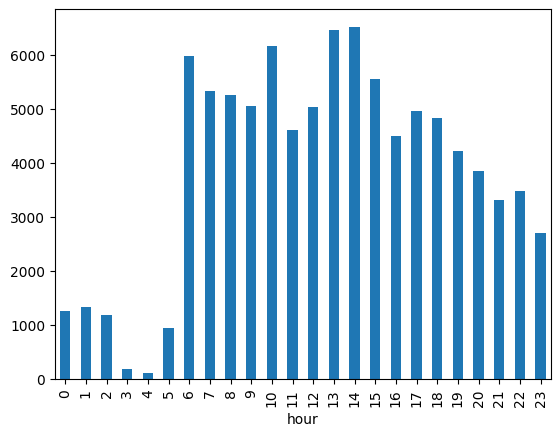

In [8]:
# Volume par heure
df_hist.groupby('hour').size().plot(kind='bar')

# Volume par jour de semaine
df_hist.groupby('weekday_name').size()

# Saisonnalité mensuelle
df_hist.groupby('month').size()

# Tendance dans le temps (resample)
df_hist.set_index('Date and Time').resample('ME').size()   # par jour
df_hist.set_index('Date and Time').resample('QE').size()   # par semaine
df_hist.set_index('Date and Time').resample('YE').size()   # par mois


In [9]:
df_hist['Aircraft Type'].value_counts()

Aircraft Type
C    82957
D     4117
B     3883
E     1975
A       10
Name: count, dtype: int64

In [10]:
df_hist['Arrival / Departure' ].value_counts()

Arrival / Departure
D    46480
A    46462
Name: count, dtype: int64

In [11]:
df_hist['Passenger/Cargo'].value_counts()

Passenger/Cargo
Commercial     88605
Cargo           3178
Positioning     1159
Name: count, dtype: int64

In [12]:
df_hist['Origin / Destination'].value_counts(normalize=True)


Origin / Destination
LHR    0.056325
DUB    0.055680
AMS    0.036614
STN    0.036485
CDG    0.029965
         ...   
JED    0.000011
RDU    0.000011
XFW    0.000011
BGR    0.000011
VIT    0.000011
Name: proportion, Length: 222, dtype: float64

# Feature engineering

In [13]:
df_hist.isna().sum()

Date and Time           0
Passenger/Cargo         0
Flight ID               0
Turnaround Flight ID    0
Arrival / Departure     0
Aircraft Type           0
Airline                 0
Origin / Destination    0
hour                    0
minute                  0
weekday                 0
weekday_name            0
day                     0
month                   0
month_name              0
quarter                 0
year                    0
week                    0
is_weekend              0
hour_sin                0
hour_cos                0
month_sin               0
month_cos               0
weekday_sin             0
weekday_cos             0
dtype: int64

Je veux construire un modele qui peut s'entrainer sur ces données pour que dans le futrure, quand y'a un avion qui arrive, et que sur le schedule y'a des vols de départs, dans 3h, 1H, 30 min....., le modele va attribuer des scores de probabilité de correspondance entre les vols d'arrivées et les vols de départs, en se basant sur les caractéristiques des vols et les données historiques de correspondances réussies.

In [14]:
df_hist.head()

,Date and Time,Passenger/Cargo,Flight ID,Turnaround Flight ID,Arrival / Departure,Aircraft Type,Airline,Origin / Destination,hour,minute,...,quarter,year,week,is_weekend,hour_sin,hour_cos,month_sin,month_cos,weekday_sin,weekday_cos
0,2023-06-01 00:00:00,Commercial,2719556,2655707,A,C,FR,VLC,0,0,...,2,2023,22,0,0.000000,1.000000,1.224647e-16,-1.0,0.433884,-0.900969
1,2023-06-01 00:05:00,Commercial,2719557,2655734,A,C,FR,KUN,0,5,...,2,2023,22,0,0.000000,1.000000,1.224647e-16,-1.0,0.433884,-0.900969
2,2023-06-01 00:15:00,Commercial,2655685,2719558,A,C,FR,OPO,0,15,...,2,2023,22,0,0.000000,1.000000,1.224647e-16,-1.0,0.433884,-0.900969
3,2023-06-01 00:30:00,Commercial,2655686,2655729,A,C,U2,DLM,0,30,...,2,2023,22,0,0.000000,1.000000,1.224647e-16,-1.0,0.433884,-0.900969
4,2023-06-01 01:10:00,Cargo,2742844,2655967,A,C,NPT,STN,1,10,...,2,2023,22,0,0.258819,0.965926,1.224647e-16,-1.0,0.433884,-0.900969


Faut entrainer le modele sur des liens, donc faut identifier les vols qui ont le meme turnaround flight ID

In [15]:
# 1. SPLIT TEMPOREL
split_date = df_hist['Date and Time'].quantile(0.8)

df_train_raw = df_hist[df_hist['Date and Time'] <= split_date]
df_test_raw  = df_hist[df_hist['Date and Time'] > split_date]

# 2. Séparer arrivées et départs
df_arr_train = df_train_raw[df_train_raw['Arrival / Departure'] == 'A']
df_dep_train = df_train_raw[df_train_raw['Arrival / Departure'] == 'D']

df_arr_test = df_test_raw[df_test_raw['Arrival / Departure'] == 'A']
df_dep_test = df_test_raw[df_test_raw['Arrival / Departure'] == 'D']

# 3. Merge train
df_train = df_arr_train.merge(
    df_dep_train,
    left_on='Turnaround Flight ID',
    right_on='Flight ID',
    suffixes=('_arr', '_dep')
)

# 4. Merge test
df_test = df_arr_test.merge(
    df_dep_test,
    left_on='Turnaround Flight ID',
    right_on='Flight ID',
    suffixes=('_arr', '_dep')
)

print(df_train.shape, df_test.shape)


(37076, 50) (9267, 50)


In [16]:
df_train.columns

Index(['Date and Time_arr', 'Passenger/Cargo_arr', 'Flight ID_arr',
       'Turnaround Flight ID_arr', 'Arrival / Departure_arr',
       'Aircraft Type_arr', 'Airline_arr', 'Origin / Destination_arr',
       'hour_arr', 'minute_arr', 'weekday_arr', 'weekday_name_arr', 'day_arr',
       'month_arr', 'month_name_arr', 'quarter_arr', 'year_arr', 'week_arr',
       'is_weekend_arr', 'hour_sin_arr', 'hour_cos_arr', 'month_sin_arr',
       'month_cos_arr', 'weekday_sin_arr', 'weekday_cos_arr',
       'Date and Time_dep', 'Passenger/Cargo_dep', 'Flight ID_dep',
       'Turnaround Flight ID_dep', 'Arrival / Departure_dep',
       'Aircraft Type_dep', 'Airline_dep', 'Origin / Destination_dep',
       'hour_dep', 'minute_dep', 'weekday_dep', 'weekday_name_dep', 'day_dep',
       'month_dep', 'month_name_dep', 'quarter_dep', 'year_dep', 'week_dep',
       'is_weekend_dep', 'hour_sin_dep', 'hour_cos_dep', 'month_sin_dep',
       'month_cos_dep', 'weekday_sin_dep', 'weekday_cos_dep'],
      dtype='

### Generer des paires negatives pour que le modele apprenne sur les deux

In [17]:
from datetime import timedelta

def generate_negatives(df_arr, df_dep, time_window=12):
    negatives = []
    
    for _, arr in df_arr.iterrows():
        heure_arr = arr['Date and Time']
        vrai_turnaround = arr['Turnaround Flight ID']
        
        mask = (
            (df_dep['Date and Time'] >= heure_arr) &
            (df_dep['Date and Time'] <= heure_arr + timedelta(hours=time_window)) &
            (df_dep['Flight ID'] != vrai_turnaround)
        )
        
        faux_departs = df_dep[mask]
        
        if len(faux_departs) > 0:
            neg = faux_departs.sample(1).copy()
            neg['Flight ID_arr'] = arr['Flight ID']
            neg['label'] = 0
            negatives.append(neg)
    
    return pd.concat(negatives)

df_neg_train = generate_negatives(df_arr_train, df_dep_train)


In [18]:
df_neg_test = generate_negatives(df_arr_test, df_dep_test)

In [19]:
df_neg_train

,Date and Time,Passenger/Cargo,Flight ID,Turnaround Flight ID,Arrival / Departure,Aircraft Type,Airline,Origin / Destination,hour,minute,...,week,is_weekend,hour_sin,hour_cos,month_sin,month_cos,weekday_sin,weekday_cos,Flight ID_arr,label
45,2023-06-01 07:00:00,Commercial,2655728,2749224,D,C,U2,BFS,7,0,...,22,0,0.965926,-0.258819,1.224647e-16,-1.000000,0.433884,-0.900969,2719556,0
110,2023-06-01 11:35:00,Commercial,2655804,2655798,D,C,FR,NTE,11,35,...,22,0,0.258819,-0.965926,1.224647e-16,-1.000000,0.433884,-0.900969,2719557,0
82,2023-06-01 10:00:00,Commercial,2655773,2655759,D,C,AY,HEL,10,0,...,22,0,0.500000,-0.866025,1.224647e-16,-1.000000,0.433884,-0.900969,2655685,0
85,2023-06-01 10:05:00,Commercial,2655777,2655764,D,C,U2,AMS,10,5,...,22,0,0.500000,-0.866025,1.224647e-16,-1.000000,0.433884,-0.900969,2655686,0
96,2023-06-01 10:40:00,Commercial,2736426,2736425,D,C,BA,LCY,10,40,...,22,0,0.500000,-0.866025,1.224647e-16,-1.000000,0.433884,-0.900969,2742844,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74352,2025-07-11 10:30:00,Commercial,3264794,3227087,D,B,LM,SYY,10,30,...,28,0,0.500000,-0.866025,-5.000000e-01,-0.866025,-0.433884,-0.900969,3225075,0
74350,2025-07-11 10:25:00,Commercial,3148244,3148227,D,C,U2,STN,10,25,...,28,0,0.500000,-0.866025,-5.000000e-01,-0.866025,-0.433884,-0.900969,3148236,0
74350,2025-07-11 10:25:00,Commercial,3148244,3148227,D,C,U2,STN,10,25,...,28,0,0.500000,-0.866025,-5.000000e-01,-0.866025,-0.433884,-0.900969,3148240,0
74352,2025-07-11 10:30:00,Commercial,3264794,3227087,D,B,LM,SYY,10,30,...,28,0,0.500000,-0.866025,-5.000000e-01,-0.866025,-0.433884,-0.900969,3148238,0


In [20]:
# display all columns
pd.set_option('display.max_columns', None)
df_train.head()

,Date and Time_arr,Passenger/Cargo_arr,Flight ID_arr,Turnaround Flight ID_arr,Arrival / Departure_arr,Aircraft Type_arr,Airline_arr,Origin / Destination_arr,hour_arr,minute_arr,weekday_arr,weekday_name_arr,day_arr,month_arr,month_name_arr,quarter_arr,year_arr,week_arr,is_weekend_arr,hour_sin_arr,hour_cos_arr,month_sin_arr,month_cos_arr,weekday_sin_arr,weekday_cos_arr,Date and Time_dep,Passenger/Cargo_dep,Flight ID_dep,Turnaround Flight ID_dep,Arrival / Departure_dep,Aircraft Type_dep,Airline_dep,Origin / Destination_dep,hour_dep,minute_dep,weekday_dep,weekday_name_dep,day_dep,month_dep,month_name_dep,quarter_dep,year_dep,week_dep,is_weekend_dep,hour_sin_dep,hour_cos_dep,month_sin_dep,month_cos_dep,weekday_sin_dep,weekday_cos_dep
0,2023-06-01 00:00:00,Commercial,2719556,2655707,A,C,FR,VLC,0,0,3,Thursday,1,6,June,2,2023,22,0,0.000000,1.000000,1.224647e-16,-1.0,0.433884,-0.900969,2023-06-01 06:10:00,Commercial,2655707,2719556,D,C,FR,ACE,6,10,3,Thursday,1,6,June,2,2023,22,0,1.000000,6.123234e-17,1.224647e-16,-1.0,0.433884,-0.900969
1,2023-06-01 00:05:00,Commercial,2719557,2655734,A,C,FR,KUN,0,5,3,Thursday,1,6,June,2,2023,22,0,0.000000,1.000000,1.224647e-16,-1.0,0.433884,-0.900969,2023-06-01 07:40:00,Commercial,2655734,2719557,D,C,FR,PMI,7,40,3,Thursday,1,6,June,2,2023,22,0,0.965926,-2.588190e-01,1.224647e-16,-1.0,0.433884,-0.900969
2,2023-06-01 00:15:00,Commercial,2655685,2719558,A,C,FR,OPO,0,15,3,Thursday,1,6,June,2,2023,22,0,0.000000,1.000000,1.224647e-16,-1.0,0.433884,-0.900969,2023-06-01 07:00:00,Commercial,2719558,2655685,D,C,FR,BRI,7,0,3,Thursday,1,6,June,2,2023,22,0,0.965926,-2.588190e-01,1.224647e-16,-1.0,0.433884,-0.900969
3,2023-06-01 00:30:00,Commercial,2655686,2655729,A,C,U2,DLM,0,30,3,Thursday,1,6,June,2,2023,22,0,0.000000,1.000000,1.224647e-16,-1.0,0.433884,-0.900969,2023-06-01 07:00:00,Commercial,2655729,2655686,D,C,U2,NCE,7,0,3,Thursday,1,6,June,2,2023,22,0,0.965926,-2.588190e-01,1.224647e-16,-1.0,0.433884,-0.900969
4,2023-06-01 01:10:00,Cargo,2742844,2655967,A,C,NPT,STN,1,10,3,Thursday,1,6,June,2,2023,22,0,0.258819,0.965926,1.224647e-16,-1.0,0.433884,-0.900969,2023-06-01 21:40:00,Cargo,2655967,2742844,D,C,NPT,STN,21,40,3,Thursday,1,6,June,2,2023,22,0,-0.707107,7.071068e-01,1.224647e-16,-1.0,0.433884,-0.900969


## Create Turnaround Time (Hours)

In [21]:
df_train['Turnaround Time'] = (
    df_train['Date and Time_dep'] - df_train['Date and Time_arr']
).dt.total_seconds() / 3600

df_test['Turnaround Time'] = (
    df_test['Date and Time_dep'] - df_test['Date and Time_arr']
).dt.total_seconds() / 3600


In [22]:
df_train['Turnaround Time'].describe()

count    37076.000000
mean         3.094521
std          6.558539
min        -12.916667
25%          0.583333
50%          0.833333
75%          3.083333
max        313.166667
Name: Turnaround Time, dtype: float64

In [23]:
df_test['Turnaround Time'].describe()

count    9267.000000
mean        2.766906
std         5.353164
min        -3.666667
25%         0.583333
50%         0.833333
75%         2.166667
max       118.833333
Name: Turnaround Time, dtype: float64

### Encodage de Cargo/Passenger avec one hot encoding

In [24]:
df_train['Passenger/Cargo_arr'].value_counts(normalize=True)*100 ,df_test['Passenger/Cargo_arr'].value_counts(normalize=True)*100


(Passenger/Cargo_arr
 Commercial     94.826842
 Cargo           3.881217
 Positioning     1.291941
 Name: proportion, dtype: float64,
 Passenger/Cargo_arr
 Commercial     97.474911
 Cargo           2.071868
 Positioning     0.453221
 Name: proportion, dtype: float64)

Cargo and Positioning flights represent less than 5% of the dataset combined, which could introduce bias in our model. To address this, we create a binary variable equal to 1 if the flight is Commercial, and 0 otherwise.

In [25]:
# Train
df_train['is_commercial_arr'] = (df_train['Passenger/Cargo_arr'] == 'Commercial').astype(int)
df_train['is_commercial_dep'] = (df_train['Passenger/Cargo_dep'] == 'Commercial').astype(int)

# Test
df_test['is_commercial_arr'] = (df_test['Passenger/Cargo_arr'] == 'Commercial').astype(int)
df_test['is_commercial_dep'] = (df_test['Passenger/Cargo_dep'] == 'Commercial').astype(int)


for Arrival / Departure, after the merge the colmuns are either D or A, so we can drop them

In [26]:
# Train
df_train.drop(columns=['Arrival / Departure_arr', 'Arrival / Departure_dep'], inplace=True, errors='ignore')

# Test
df_test.drop(columns=['Arrival / Departure_arr', 'Arrival / Departure_dep'], inplace=True, errors='ignore')


In [27]:
# Train
df_train.drop(columns=['Aircraft Type_dep'], inplace=True, errors='ignore')
df_train.rename(columns={'Aircraft Type_arr': 'Aircraft Type'}, inplace=True)

# Test
df_test.drop(columns=['Aircraft Type_dep'], inplace=True, errors='ignore')
df_test.rename(columns={'Aircraft Type_arr': 'Aircraft Type'}, inplace=True)


## Aircraft Categories

- **Category A**: less than 169 km/h (91 knots) indicated airspeed (IAS)
- **Category B**: 169 km/h (91 knots) or more but less than 224 km/h (121 knots) IAS
- **Category C**: 224 km/h (121 knots) or more but less than 261 km/h (141 knots) IAS
- **Category D**: 261 km/h (141 knots) or more but less than 307 km/h (166 knots) IAS
- **Category E**: 307 km/h (166 knots) or more but less than 391 km/h (211 knots) IAS

SO it's in an order, from lower to higher , we can map the categories from 1 to 5

In [28]:
size_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5}

# Train
df_train['Aircraft Size'] = df_train['Aircraft Type'].map(size_map)
df_train.drop(columns=['Aircraft Type'], inplace=True, errors='ignore')

# Test
df_test['Aircraft Size'] = df_test['Aircraft Type'].map(size_map)
df_test.drop(columns=['Aircraft Type'], inplace=True, errors='ignore')


## Origin / Destination
#### Creating pairs from departure to arrival, to see specific route patterns

In [29]:
# Juste créer la colonne, PAS de frequency encoding encore
df_train['route_pair'] = df_train['Origin / Destination_arr'] + '_' + df_train['Origin / Destination_dep']
df_test['route_pair'] = df_test['Origin / Destination_arr'] + '_' + df_test['Origin / Destination_dep']

# Drop les colonnes originales
df_train.drop(columns=['Origin / Destination_arr', 'Origin / Destination_dep'], inplace=True)
df_test.drop(columns=['Origin / Destination_arr', 'Origin / Destination_dep'], inplace=True)


## Airline

In [30]:
(df_train['Airline_arr']==df_train['Airline_dep']).all()

np.False_

In [31]:
(df_train['Airline_arr'] != df_train['Airline_dep']).sum()

np.int64(104)

In [32]:
df_train[df_train['Airline_arr'] != df_train['Airline_dep']][['Airline_arr', 'Airline_dep']].value_counts()

Airline_arr  Airline_dep
RK           FR             43
FR           RK             42
NPT          7J              4
SWN          NPT             3
U2           EC              2
FX           ABR             2
             3V              2
7J           NPT             2
EC           U2              1
EI           EA              1
NPT          SWN             1
3V           FX              1
Name: count, dtype: int64

## Mapper les DEP_ARR et calculer leurs frequences

In [33]:
# Juste créer la colonne, PAS de frequency encoding encore
df_train['airline_pair'] = df_train['Airline_arr'] + '_' + df_train['Airline_dep']
df_test['airline_pair'] = df_test['Airline_arr'] + '_' + df_test['Airline_dep']

# Drop les colonnes originales
df_train.drop(columns=['Airline_arr', 'Airline_dep'], inplace=True)
df_test.drop(columns=['Airline_arr', 'Airline_dep'], inplace=True)


In [34]:
df_train.head()

,Date and Time_arr,Passenger/Cargo_arr,Flight ID_arr,Turnaround Flight ID_arr,hour_arr,minute_arr,weekday_arr,weekday_name_arr,day_arr,month_arr,month_name_arr,quarter_arr,year_arr,week_arr,is_weekend_arr,hour_sin_arr,hour_cos_arr,month_sin_arr,month_cos_arr,weekday_sin_arr,weekday_cos_arr,Date and Time_dep,Passenger/Cargo_dep,Flight ID_dep,Turnaround Flight ID_dep,hour_dep,minute_dep,weekday_dep,weekday_name_dep,day_dep,month_dep,month_name_dep,quarter_dep,year_dep,week_dep,is_weekend_dep,hour_sin_dep,hour_cos_dep,month_sin_dep,month_cos_dep,weekday_sin_dep,weekday_cos_dep,Turnaround Time,is_commercial_arr,is_commercial_dep,Aircraft Size,route_pair,airline_pair
0,2023-06-01 00:00:00,Commercial,2719556,2655707,0,0,3,Thursday,1,6,June,2,2023,22,0,0.000000,1.000000,1.224647e-16,-1.0,0.433884,-0.900969,2023-06-01 06:10:00,Commercial,2655707,2719556,6,10,3,Thursday,1,6,June,2,2023,22,0,1.000000,6.123234e-17,1.224647e-16,-1.0,0.433884,-0.900969,6.166667,1,1,3,VLC_ACE,FR_FR
1,2023-06-01 00:05:00,Commercial,2719557,2655734,0,5,3,Thursday,1,6,June,2,2023,22,0,0.000000,1.000000,1.224647e-16,-1.0,0.433884,-0.900969,2023-06-01 07:40:00,Commercial,2655734,2719557,7,40,3,Thursday,1,6,June,2,2023,22,0,0.965926,-2.588190e-01,1.224647e-16,-1.0,0.433884,-0.900969,7.583333,1,1,3,KUN_PMI,FR_FR
2,2023-06-01 00:15:00,Commercial,2655685,2719558,0,15,3,Thursday,1,6,June,2,2023,22,0,0.000000,1.000000,1.224647e-16,-1.0,0.433884,-0.900969,2023-06-01 07:00:00,Commercial,2719558,2655685,7,0,3,Thursday,1,6,June,2,2023,22,0,0.965926,-2.588190e-01,1.224647e-16,-1.0,0.433884,-0.900969,6.750000,1,1,3,OPO_BRI,FR_FR
3,2023-06-01 00:30:00,Commercial,2655686,2655729,0,30,3,Thursday,1,6,June,2,2023,22,0,0.000000,1.000000,1.224647e-16,-1.0,0.433884,-0.900969,2023-06-01 07:00:00,Commercial,2655729,2655686,7,0,3,Thursday,1,6,June,2,2023,22,0,0.965926,-2.588190e-01,1.224647e-16,-1.0,0.433884,-0.900969,6.500000,1,1,3,DLM_NCE,U2_U2
4,2023-06-01 01:10:00,Cargo,2742844,2655967,1,10,3,Thursday,1,6,June,2,2023,22,0,0.258819,0.965926,1.224647e-16,-1.0,0.433884,-0.900969,2023-06-01 21:40:00,Cargo,2655967,2742844,21,40,3,Thursday,1,6,June,2,2023,22,0,-0.707107,7.071068e-01,1.224647e-16,-1.0,0.433884,-0.900969,20.500000,0,0,3,STN_STN,NPT_NPT


### Working on date and time

In [35]:
for df in [df_train, df_test]:
    df['hour_arr'] = df['Date and Time_arr'].dt.hour
    df['hour_dep'] = df['Date and Time_dep'].dt.hour
    df['day_of_week'] = df['Date and Time_arr'].dt.dayofweek
    df['month'] = df['Date and Time_arr'].dt.month
    df.drop(columns=['Date and Time_arr', 'Date and Time_dep'], inplace=True)


In [36]:
df_train.head()

,Passenger/Cargo_arr,Flight ID_arr,Turnaround Flight ID_arr,hour_arr,minute_arr,weekday_arr,weekday_name_arr,day_arr,month_arr,month_name_arr,quarter_arr,year_arr,week_arr,is_weekend_arr,hour_sin_arr,hour_cos_arr,month_sin_arr,month_cos_arr,weekday_sin_arr,weekday_cos_arr,Passenger/Cargo_dep,Flight ID_dep,Turnaround Flight ID_dep,hour_dep,minute_dep,weekday_dep,weekday_name_dep,day_dep,month_dep,month_name_dep,quarter_dep,year_dep,week_dep,is_weekend_dep,hour_sin_dep,hour_cos_dep,month_sin_dep,month_cos_dep,weekday_sin_dep,weekday_cos_dep,Turnaround Time,is_commercial_arr,is_commercial_dep,Aircraft Size,route_pair,airline_pair,day_of_week,month
0,Commercial,2719556,2655707,0,0,3,Thursday,1,6,June,2,2023,22,0,0.000000,1.000000,1.224647e-16,-1.0,0.433884,-0.900969,Commercial,2655707,2719556,6,10,3,Thursday,1,6,June,2,2023,22,0,1.000000,6.123234e-17,1.224647e-16,-1.0,0.433884,-0.900969,6.166667,1,1,3,VLC_ACE,FR_FR,3,6
1,Commercial,2719557,2655734,0,5,3,Thursday,1,6,June,2,2023,22,0,0.000000,1.000000,1.224647e-16,-1.0,0.433884,-0.900969,Commercial,2655734,2719557,7,40,3,Thursday,1,6,June,2,2023,22,0,0.965926,-2.588190e-01,1.224647e-16,-1.0,0.433884,-0.900969,7.583333,1,1,3,KUN_PMI,FR_FR,3,6
2,Commercial,2655685,2719558,0,15,3,Thursday,1,6,June,2,2023,22,0,0.000000,1.000000,1.224647e-16,-1.0,0.433884,-0.900969,Commercial,2719558,2655685,7,0,3,Thursday,1,6,June,2,2023,22,0,0.965926,-2.588190e-01,1.224647e-16,-1.0,0.433884,-0.900969,6.750000,1,1,3,OPO_BRI,FR_FR,3,6
3,Commercial,2655686,2655729,0,30,3,Thursday,1,6,June,2,2023,22,0,0.000000,1.000000,1.224647e-16,-1.0,0.433884,-0.900969,Commercial,2655729,2655686,7,0,3,Thursday,1,6,June,2,2023,22,0,0.965926,-2.588190e-01,1.224647e-16,-1.0,0.433884,-0.900969,6.500000,1,1,3,DLM_NCE,U2_U2,3,6
4,Cargo,2742844,2655967,1,10,3,Thursday,1,6,June,2,2023,22,0,0.258819,0.965926,1.224647e-16,-1.0,0.433884,-0.900969,Cargo,2655967,2742844,21,40,3,Thursday,1,6,June,2,2023,22,0,-0.707107,7.071068e-01,1.224647e-16,-1.0,0.433884,-0.900969,20.500000,0,0,3,STN_STN,NPT_NPT,3,6


In [37]:
cols = [
    'Turnaround Time',
    'is_commercial_arr',
    'is_commercial_dep',
    'Aircraft Size',
    'route_pair',
    'airline_pair',
    'hour_arr',
    'hour_dep',
    'day_of_week',
    'month'
]

df_train_final = df_train[cols].copy()
df_test_final = df_test[cols].copy()


In [38]:
df_train_final.head()

,Turnaround Time,is_commercial_arr,is_commercial_dep,Aircraft Size,route_pair,airline_pair,hour_arr,hour_dep,day_of_week,month
0,6.166667,1,1,3,VLC_ACE,FR_FR,0,6,3,6
1,7.583333,1,1,3,KUN_PMI,FR_FR,0,7,3,6
2,6.750000,1,1,3,OPO_BRI,FR_FR,0,7,3,6
3,6.500000,1,1,3,DLM_NCE,U2_U2,0,7,3,6
4,20.500000,0,0,3,STN_STN,NPT_NPT,1,21,3,6


## Handle Time

Text(0.5, 1.0, 'Distribution des heures de départ')

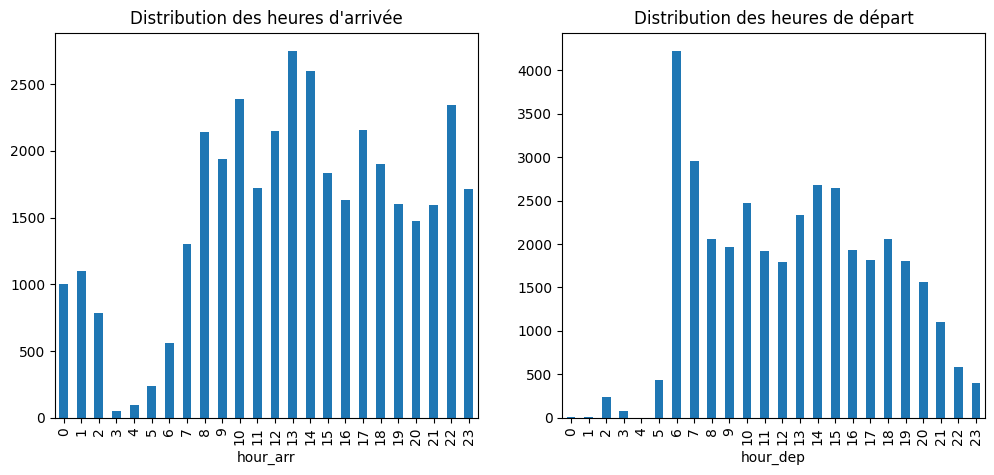

In [39]:
# faire un bar plot sur les heures d'arrivée et de départ
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df_train_final['hour_arr'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution des heures d\'arrivée')
plt.subplot(1, 2, 2)
df_train_final['hour_dep'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution des heures de départ')


In [40]:
df_train_final.isnull().sum(), df_test_final.isnull().sum()

(Turnaround Time      0
 is_commercial_arr    0
 is_commercial_dep    0
 Aircraft Size        0
 route_pair           0
 airline_pair         0
 hour_arr             0
 hour_dep             0
 day_of_week          0
 month                0
 dtype: int64,
 Turnaround Time      0
 is_commercial_arr    0
 is_commercial_dep    0
 Aircraft Size        0
 route_pair           0
 airline_pair         0
 hour_arr             0
 hour_dep             0
 day_of_week          0
 month                0
 dtype: int64)

## meme Feature engeneering sur les negatives 

In [41]:
# Récupérer les infos de l'arrivée via Flight ID_arr
df_neg_train_merged = df_neg_train.merge(
    df_arr_train[['Flight ID', 'Date and Time', 'Passenger/Cargo', 
                  'Aircraft Type', 'Airline', 'Origin / Destination']].rename(columns={
        'Flight ID': 'Flight ID_arr_key',
        'Date and Time': 'Date and Time_arr',
        'Passenger/Cargo': 'Passenger/Cargo_arr',
        'Aircraft Type': 'Aircraft Type_arr',
        'Airline': 'Airline_arr',
        'Origin / Destination': 'Origin / Destination_arr'
    }),
    left_on='Flight ID_arr',
    right_on='Flight ID_arr_key'
).drop(columns=['Flight ID_arr_key'])

df_neg_test_merged = df_neg_test.merge(
    df_arr_test[['Flight ID', 'Date and Time', 'Passenger/Cargo',
                 'Aircraft Type', 'Airline', 'Origin / Destination']].rename(columns={
        'Flight ID': 'Flight ID_arr_key',
        'Date and Time': 'Date and Time_arr',
        'Passenger/Cargo': 'Passenger/Cargo_arr',
        'Aircraft Type': 'Aircraft Type_arr',
        'Airline': 'Airline_arr',
        'Origin / Destination': 'Origin / Destination_arr'
    }),
    left_on='Flight ID_arr',
    right_on='Flight ID_arr_key'
).drop(columns=['Flight ID_arr_key'])

print(df_neg_train_merged.shape, df_neg_test_merged.shape)


(37148, 32) (9283, 32)


In [42]:
def feature_engineering_negatives(df, size_map):
    df = df.copy()
    
    # Turnaround Time
    df['Turnaround Time'] = (
        df['Date and Time'] - df['Date and Time_arr']
    ).dt.total_seconds() / 3600
    
    # is_commercial
    df['is_commercial_arr'] = (df['Passenger/Cargo_arr'] == 'Commercial').astype(int)
    df['is_commercial_dep'] = (df['Passenger/Cargo'] == 'Commercial').astype(int)
    
    # Aircraft Size
    df['Aircraft Size'] = df['Aircraft Type_arr'].map(size_map)
    
    # Route pair et airline pair — PAS de freq encoding encore
    df['route_pair'] = df['Origin / Destination_arr'] + '_' + df['Origin / Destination']
    df['airline_pair'] = df['Airline_arr'] + '_' + df['Airline']
    
    # Features temporelles
    df['hour_arr'] = df['Date and Time_arr'].dt.hour
    df['hour_dep'] = df['Date and Time'].dt.hour
    df['day_of_week'] = df['Date and Time_arr'].dt.dayofweek
    df['month'] = df['Date and Time_arr'].dt.month
    
    df['label'] = 0
    
    cols = [
        'Turnaround Time', 'is_commercial_arr', 'is_commercial_dep',
        'Aircraft Size', 'route_pair', 'airline_pair',
        'hour_arr', 'hour_dep', 'day_of_week', 'month', 'label'
    ]
    
    return df[cols]

df_neg_train_final = feature_engineering_negatives(df_neg_train_merged, size_map)
df_neg_test_final = feature_engineering_negatives(df_neg_test_merged, size_map)

print(df_neg_train_final.shape, df_neg_test_final.shape)


(37148, 11) (9283, 11)


In [43]:
# Labels
df_train_final['label'] = 1
df_test_final['label'] = 1

# Combiner positifs + négatifs
df_train_full = pd.concat([df_train_final, df_neg_train_final], ignore_index=True)
df_test_full  = pd.concat([df_test_final,  df_neg_test_final],  ignore_index=True)

# Frequency encoding sur toutes les paires MAINTENANT (positifs + négatifs)
freq_route = df_train_full['route_pair'].value_counts(normalize=True) * 100
freq_pair  = df_train_full['airline_pair'].value_counts(normalize=True)

df_train_full['route_pair_freq']   = df_train_full['route_pair'].map(freq_route)
df_test_full['route_pair_freq']    = df_test_full['route_pair'].map(freq_route).fillna(0)

df_train_full['airline_pair_freq'] = df_train_full['airline_pair'].map(freq_pair)
df_test_full['airline_pair_freq']  = df_test_full['airline_pair'].map(freq_pair).fillna(0)

# Drop les colonnes texte
df_train_full.drop(columns=['route_pair', 'airline_pair'], inplace=True)
df_test_full.drop(columns=['route_pair', 'airline_pair'], inplace=True)

print(df_train_full.shape, df_test_full.shape)
print(df_train_full['label'].value_counts())
print(df_test_full['label'].value_counts())


(74224, 11) (18550, 11)
label
0    37148
1    37076
Name: count, dtype: int64
label
0    9283
1    9267
Name: count, dtype: int64


#### The datasets are initially Ready for modeling

# Modele : Xgboost

In [44]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Features et labels
X_train = df_train_full.drop(columns=['label'])
y_train = df_train_full['label']

X_test = df_test_full.drop(columns=['label'])
y_test = df_test_full['label']

# Modèle
model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)

# Évaluation
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f'AUC-ROC : {roc_auc_score(y_test, y_proba):.4f}')


              precision    recall  f1-score   support

           0       0.97      0.96      0.97      9283
           1       0.96      0.97      0.97      9267

    accuracy                           0.97     18550
   macro avg       0.97      0.97      0.97     18550
weighted avg       0.97      0.97      0.97     18550

AUC-ROC : 0.9946


## Importance des variables

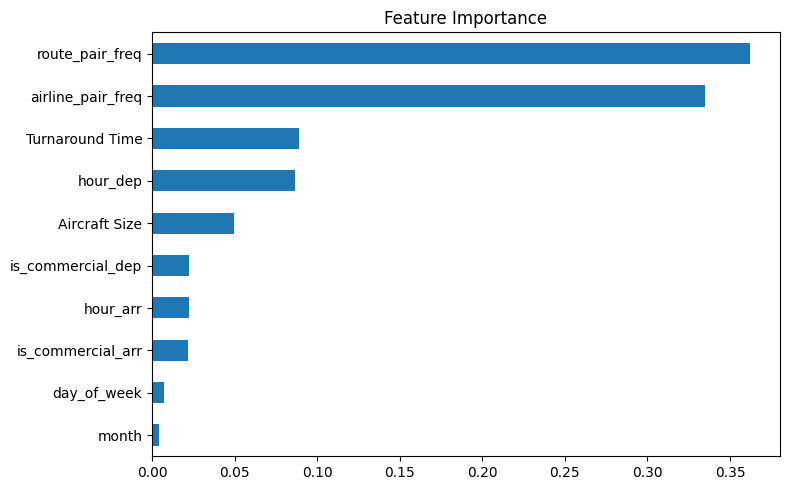

In [45]:
import matplotlib.pyplot as plt

feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(8, 5))
plt.title('Feature Importance')
plt.tight_layout()
plt.show()


## Tester s'il y a un grand risque d'overfitting

In [46]:
# Score sur train vs test
from sklearn.metrics import roc_auc_score

y_train_pred = model.predict_proba(X_train)[:, 1]
y_test_pred  = model.predict_proba(X_test)[:, 1]

print(f"AUC Train : {roc_auc_score(y_train, y_train_pred):.4f}")
print(f"AUC Test  : {roc_auc_score(y_test,  y_test_pred):.4f}")

AUC Train : 0.9948
AUC Test  : 0.9946
